In [1]:
import yt
import numpy as np
from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
import matplotlib.pyplot as plt

/tmp/ipykernel_40794/1577977597.py:3: VisibleDeprecationWarning: The yt.mods module is deprecated.
Deprecated since yt 4.1.0
This feature is planned for removal in yt 4.2.0
  from yt.mods import *


In [2]:
print(yt.__version__)

4.1.4


In [3]:
file1 = "../Outputs/TestRes/plt00000/"
file2 = "../Outputs/TestRes/plt00300/"

ds = AMReXDataset(file1, units_override = {"length_unit" : (100. , "l_pl")})
ds1 = AMReXDataset(file2, units_override = {"length_unit" : (100. , "l_pl")})

yt : [WARNING  ] 2023-05-23 19:13:09,594 Overriding code units: Use this option only if you know that the dataset doesn't define the units correctly or at all.
yt : [INFO     ] 2023-05-23 19:13:09,595 Overriding length_unit: 100.0 l_pl.
yt : [INFO     ] 2023-05-23 19:13:09,667 Parameters: current_time              = 0.0
yt : [INFO     ] 2023-05-23 19:13:09,668 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2023-05-23 19:13:09,669 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2023-05-23 19:13:09,671 Parameters: domain_right_edge         = [100. 100. 100.]
yt : [WARNING  ] 2023-05-23 19:13:09,676 Overriding code units: Use this option only if you know that the dataset doesn't define the units correctly or at all.
yt : [INFO     ] 2023-05-23 19:13:09,676 Overriding length_unit: 100.0 l_pl.
yt : [INFO     ] 2023-05-23 19:13:09,732 Parameters: current_time              = 30.0000000000002
yt : [INFO     ] 2023-05-23 19:13:09,733 Parameters: domai

In [4]:
avInit = ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
ad1 = ds1.all_data()
ad1.max_level=0
#avFin  = ds1.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
avFin  = ad1.quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
def _relField (field, data, name, av):
    return data[name]/av
def _relSqIn(field,data):
    return _relField(field, data, "Edens", avInit)
def _relSqFin(field,data):
    return _relField(field, data, "Edens", avFin)
#    return _relField(field, data, "Edens", avInit)
ds.add_field(("boxlib","EdensRel"), function=_relSqIn, sampling_type="local", units="dimensionless",force_override=True)
ds1.add_field(("boxlib","EdensRel"), function=_relSqFin, sampling_type="local", units="dimensionless", force_override=True)

In [5]:
mi, ma = ds.all_data().quantities.extrema("KGfdens")
print(ma)
print(mi)
mi, ma = ds1.all_data().quantities.extrema("KGfdens")
print(ma)
print(mi)

0.041068070760618205 dimensionless
2.975934337301807e-08 dimensionless
0.0001406881427250358 dimensionless
2.3466331669746995e-18 dimensionless


yt : [INFO     ] 2023-05-23 19:13:10,304 xlim = 0.000000 100.000000
yt : [INFO     ] 2023-05-23 19:13:10,305 ylim = 0.000000 100.000000
yt : [INFO     ] 2023-05-23 19:13:10,306 xlim = 0.000000 100.000000
yt : [INFO     ] 2023-05-23 19:13:10,306 ylim = 0.000000 100.000000
yt : [INFO     ] 2023-05-23 19:13:10,310 Making a fixed resolution buffer of (('boxlib', 'EdensRel')) 800 by 800



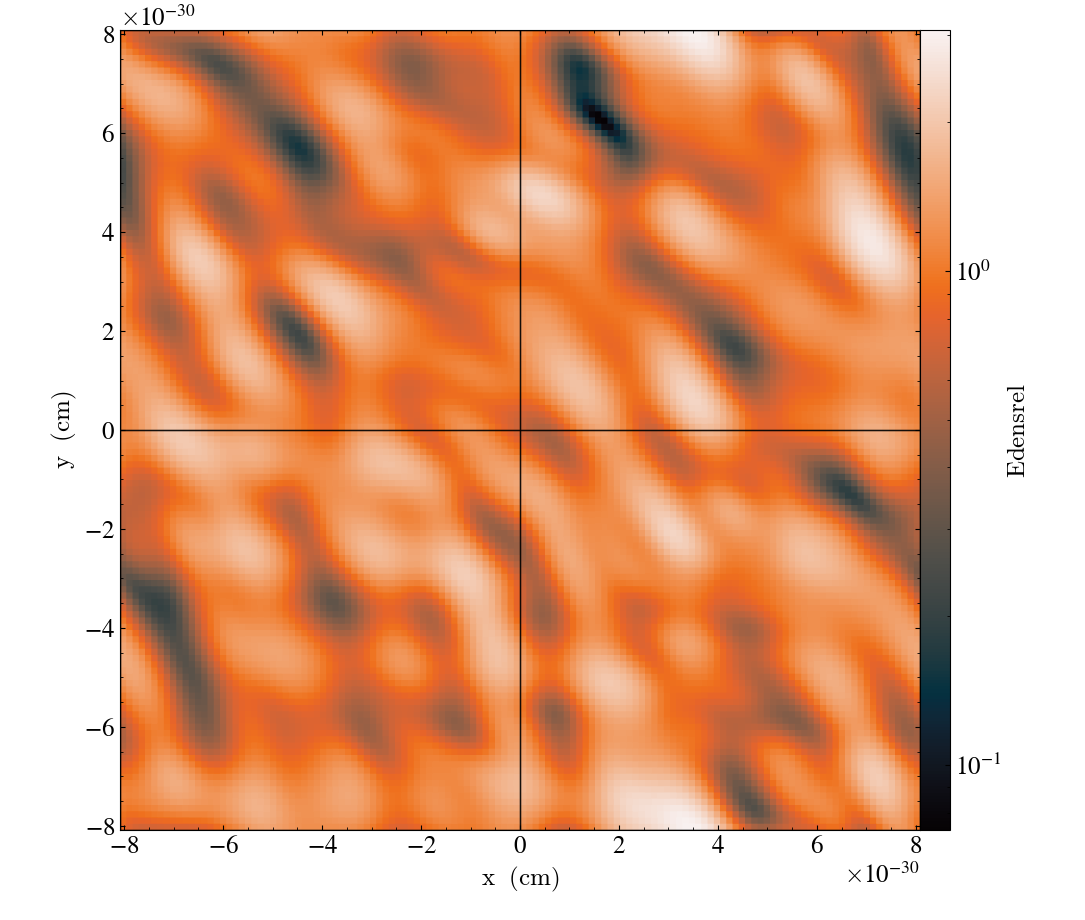

In [6]:
#%matplotlib widget
#slc = yt.ProjectionPlot(ds, "z", "AxDens")
#slc = yt.SlicePlot(ds, "z", "AxDenSq")
#slc = yt.SlicePlot(ds, "z", "axion_phase", center=[0.,0.,0.15])
#slc = yt.SlicePlot(ds, "z", "KGf", center = [2.5,2.5,0])
#slc = yt.SlicePlot(ds, "z", "KGfdens")#, center = [0,0,0])
slc = yt.SlicePlot(ds, "z", "EdensRel")#, width = (3000, "l_pl"))#, center = [0,0,0])
#slc = yt.SlicePlot(ds, "z", "KGfdens")
slc.set_cmap(field=("EdensRel"), cmap="cmyt.dusk")
#slc.set_axes_unit("l_pl")
slc.zoom(1)
#slc.set_log("Edens", False)
#slc.set_log("KGfdens", False)
#slc.set_log("EdensRel", False)
slc.annotate_grids()
#slc.show()

yt : [INFO     ] 2023-05-23 19:13:11,471 xlim = 0.000000 100.000000
yt : [INFO     ] 2023-05-23 19:13:11,472 ylim = 0.000000 100.000000
yt : [INFO     ] 2023-05-23 19:13:11,473 xlim = 0.000000 100.000000
yt : [INFO     ] 2023-05-23 19:13:11,474 ylim = 0.000000 100.000000
yt : [INFO     ] 2023-05-23 19:13:11,478 Making a fixed resolution buffer of (('boxlib', 'EdensRel')) 800 by 800



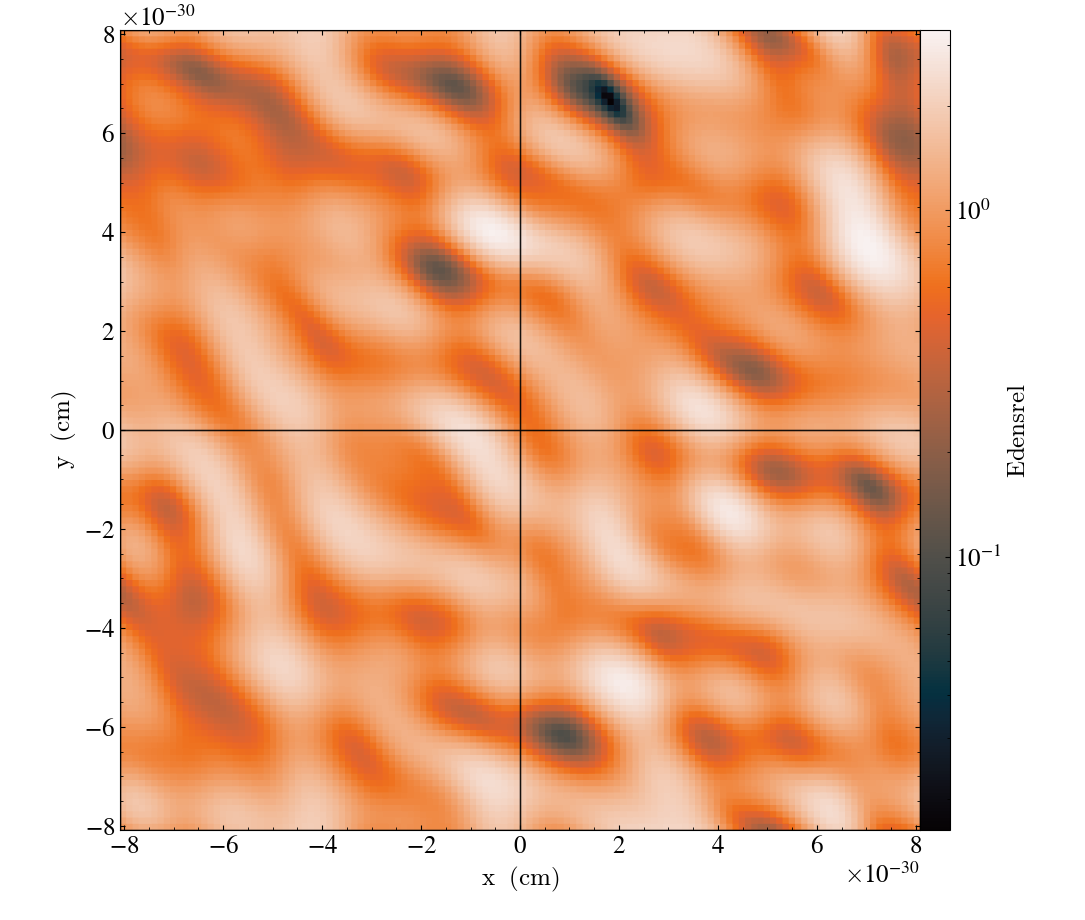

In [7]:
#slc = yt.ProjectionPlot(ds, "z", "AxDens")
#slc = yt.SlicePlot(ds, "z", "AxDenSq")
#slc = yt.SlicePlot(ds, "z", "axion_phase", center=[0.,0.,0.15])
#slc = yt.SlicePlot(ds1, "z", "KGfdens", center = [2.5,2.5,0])
ad1 = ds1.all_data()
#ad1.max_level=1
slc = yt.SlicePlot(ds1, "z", "EdensRel")#, center = [0,0,0], data_source=ad1)
#slc = yt.SlicePlot(ds1, "z", "KGfdens")#, center = [0,0,0])
slc.set_cmap(field=("EdensRel"), cmap="cmyt.dusk")
slc.zoom(1)
#slc.set_log("EdensRel", False)
#slc.set_log("KGfdens", False)
#slc.annotate_contour(("boxlib", "EdensRel"))
slc.annotate_grids()
#slc.show()

In [8]:
f3 = open(file1[:-9]+"runlog", "r")
steps3, a3, phi3, dphi3, ratio = [], [], [], [], []
f3.readline()
f3.readline()
#cnt = 0
for line in f3.readlines():
#    cnt = cnt + 1
#    if(cnt % 2 == 1):
#        continue
    fields = line.split()
    steps3.append( float(fields[0]))
    a3.append(     float(fields[3]))
    phi3.append(   float(fields[7])) # N.B. For new runlogs, phi and dphi are 7 and 8 resp., since I've added e-folds to the output.
    dphi3.append(  float(fields[8]))
    ratio.append(  float(fields[9]))
f3.close()

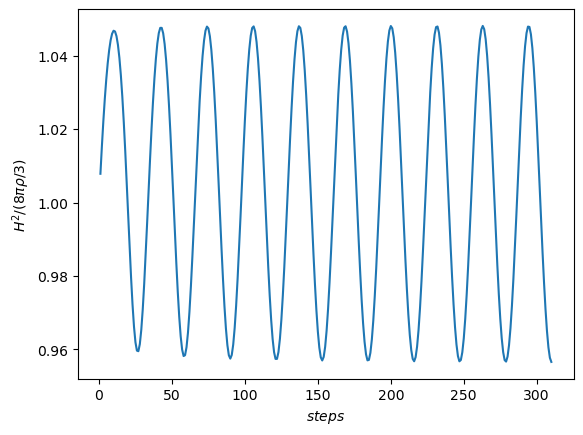

In [9]:
#%matplotlib widget
plt.plot(steps3,ratio)
plt.xlabel("$steps$")
plt.ylabel("$H^2/(8 \\pi \\rho / 3)$")
plt.show()

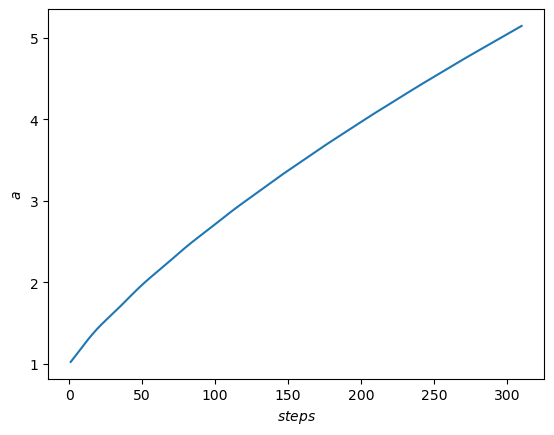

In [10]:
#%matplotlib widget
plt.plot(steps3,a3)
plt.xlabel("$steps$")
plt.ylabel("$a$")
#plt.semilogy()
plt.show()

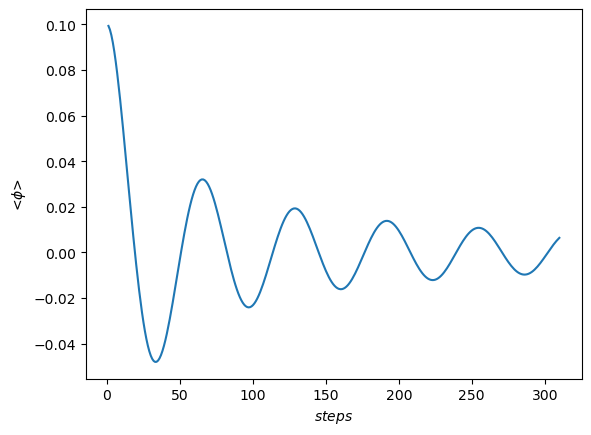

In [11]:
#%matplotlib widget
plt.plot(steps3,phi3)
plt.xlabel("$steps$")
plt.ylabel("<$\phi$>")
#plt.semilogy()
plt.show()

In [12]:
# #sc = yt.create_scene(ds1, ("boxlib", "KGfdens"), lens_type="perspective", )
# #sc = yt.create_scene(ds, ("boxlib", "EdensRel"))#, lens_type="perspective", )
# #sc.annotate_domain(ds, color=[1, 1, 1, 0.01])
# #sc.annotate_grids(ds, alpha=0.0004)
# sc = yt.create_scene(ds1, ("boxlib", "EdensRel"))#, lens_type="perspective", )
# sc.annotate_domain(ds1, color=[1, 1, 1, 0.01])
# sc.annotate_grids(ds1, alpha=0.0004)
# source = sc[0]
# source.set_field(("boxlib", "EdensRel"))
# source.set_log(True)
# source.tfh.gray_opacity = False
# #source.tfh.set_bounds((1e-15, 1e-6))
# source.tfh.set_log(True)

# #mn, mx = ds.all_data().quantities.extrema("EdensRel")
# mn, mx = ds1.all_data().quantities.extrema("EdensRel")
# if mn < 0:
#     mn = -mn
# bounds = (mn, mx)

# # Since this rendering is done in log space, the transfer function needs
# # to be specified in log space.
# tf = yt.ColorTransferFunction(np.log10(bounds))

# tf.add_layers(5, colormap="arbre")

# source.tfh.tf = tf
# source.tfh.bounds = bounds

# sc.camera.zoom(0.9)
# sc.camera.set_resolution(1000)
# #source.tfh.plot("transfer_function.png", profile_field=("boxlib", "Edens"))
# sc.show(sigma_clip=0.9)

In [13]:
# sc = yt.create_scene(ds1, ("boxlib", "EdensRel"), lens_type="plane-parallel", )
# source = sc[0]
# source.set_field(("boxlib", "EdensRel"))
# source.tfh.gray_opacity = True
# source.tfh.set_bounds((5, 20))
# source.tfh.set_log(False)
# sc.camera.zoom(0.8)
# #source.tfh.plot("transfer_function.png", profile_field=("boxlib", "KGf"))
# sc.show(sigma_clip=0.7)

In [14]:
# sc.camera.zoom(3)
# sc.render()
# sc.show(sigma_clip=3)

In [15]:
#ds1.field_list

In [16]:
# Use this if you need to plot a subset of the layers in the data
#ad1 = ds1.all_data()
#ad1.max_level=0
#slc = yt.SlicePlot(ds1, "z", "EdensRel", center = [0,0,0], data_source=ad1)